# 자유도(nu) 스윕

In [139]:
import os, csv, copy, time
from collections import OrderedDict

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import linalg
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import posterior
import autoenc
from unet import UNet

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(torch.__version__, DEVICE)

1.10.2+cu113 cuda


## 1. 설정

In [140]:
NUS      = [3.0, 5.0, 10.0, 30.0, 100.0, 300.0, 500.0, 1000.0]   # 늘려갈 자유도
DATA     = '../../data'           # FashionMNIST/raw 가 있는 곳
OUT      = 'results'                              # nu별 체크포인트/그림이 쌓이는 곳
AE       = 'results/autoenc.pt'                    # 특징공간 (autoenc.py, train_autoenc.py 가 만든다)
AE_EPOCHS = 100

LABEL    = 0            # FashionMNIST class 0 (T-shirt/top)
LIMIT    = 1000         # 확산모형 학습에 쓸 이미지 수
EPOCHS   = 100
BATCH    = 128
LR       = 2e-4
EMA      = 0.9999
TSHIFT, TSCALE = -1.74, 1.2     # t ~ sigmoid(N(tshift, tscale^2))

N_SAMPLE = 1000         # 지표용 생성 이미지 수 (실데이터 수와 맞춘다)
STEPS    = 1000          # t=1 -> t=0 denoising 스텝
CORRS    = [0.99, 1]   # sigma_12^2 = corr * sigma_t * sigma_{t-dt}
SEED     = 0

## 2. 노이징 스케줄

In [141]:
def mu(t):
    return 1.0 - t

def sigma(t):
    return t

def sigma_cross(t, t_prev, corr):
    """sigma_12^2(t) = sigma_21^2(t).  |.| <= sigma_t sigma_{t-dt} 여야 Sigma 가 PSD 이므로
    corr in [-1, 1].  corr=1 이면 sigmabar_t = 0 (결정론적 스텝)."""
    return corr * sigma(t) * sigma(t_prev)

## 3. 데이터

In [142]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full = datasets.FashionMNIST(DATA, train=True, download=True, transform=tf)

keep = torch.arange(len(full))
if LABEL is not None:
    keep = (full.targets == LABEL).nonzero(as_tuple=True)[0]
if LIMIT is not None:
    keep = keep[:LIMIT]
train_set = torch.utils.data.Subset(full, keep)

real = (full.data[keep].float() / 127.5 - 1.0).reshape(len(keep), -1).to(DEVICE)
print('%d training images  (class %s)' % (len(train_set), LABEL))

1000 training images  (class 0)


## 4. 학습: nu 하나당 모델 하나

In [143]:
def train_one(nu, out_dir, epochs=EPOCHS, verbose_every=20):
    os.makedirs(out_dir, exist_ok=True)
    loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                        num_workers=4, drop_last=True, pin_memory=True)
    net = UNet().to(DEVICE)
    ema = copy.deepcopy(net).eval().requires_grad_(False)
    opt = torch.optim.Adam(net.parameters(), lr=LR)

    step, t_start = 0, time.time()
    for epoch in range(1, epochs + 1):
        net.train()
        running = 0.0
        for x0, _ in loader:
            x0 = x0.to(DEVICE, non_blocking=True)
            t = torch.sigmoid(torch.randn(x0.shape[0], device=DEVICE) * TSCALE + TSHIFT)
            xt = posterior.sample(*posterior.perturbation_kernel(x0, mu(t), sigma(t), nu))
            loss = ((net(xt, t * 1000) - x0) ** 2).mean()          # Eqn. 10

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            with torch.no_grad():
                decay = min(EMA, (step + 1) / (step + 10))
                for pe, pn in zip(ema.parameters(), net.parameters()):
                    pe.lerp_(pn.detach(), 1 - decay)
                for be, bn in zip(ema.buffers(), net.buffers()):
                    be.copy_(bn)
            running += loss.item()
            step += 1
        if epoch % verbose_every == 0 or epoch == epochs:
            print('    epoch %3d  loss %.4f  %5.1fs' % (epoch, running / len(loader),
                                                        time.time() - t_start), flush=True)

    ck = {'ema': ema.state_dict(), 'nu': nu, 'epoch': epochs,
          'tshift': TSHIFT, 'tscale': TSCALE, 'limit': LIMIT, 'label': LABEL}
    torch.save(ck, os.path.join(out_dir, 'ckpt.pt'))
    return ema

def get_model(nu):
    """results/nu<값>/ckpt.pt 가 있으면 불러오고, 없으면 학습해서 저장한다."""
    out_dir = os.path.join(OUT, 'nu%g' % nu)
    path = os.path.join(out_dir, 'ckpt.pt')
    if os.path.exists(path):
        ck = torch.load(path, map_location=DEVICE)
        net = UNet().to(DEVICE)
        net.load_state_dict(ck['ema'])
        print('  nu=%-5g loaded %s (epoch %s, limit %s)'
              % (nu, path, ck.get('epoch'), ck.get('limit')))
        if ck.get('epoch') != EPOCHS or ck.get('limit') != LIMIT:
            print('    주의: 저장된 설정이 현재 EPOCHS=%s LIMIT=%s 와 다릅니다. '
                  '다시 학습하려면 %s 를 지우세요.' % (EPOCHS, LIMIT, path))
        return net.eval()
    print('  nu=%-5g training -> %s' % (nu, path), flush=True)
    torch.manual_seed(SEED)
    return train_one(nu, out_dir).eval()

## 5. 샘플링

In [144]:
@torch.no_grad()
def generate(net, n, nu, corr, steps=STEPS, batch=500, tag=''):
    ts = torch.linspace(1.0, 0.0, steps + 1, device=DEVICE)
    out, t0 = [], time.time()
    for i in range(0, n, batch):
        m = min(batch, n - i)
        x = posterior.sample(*posterior.prior((m, 1, 28, 28), nu, DEVICE))    # sigma_T = 1
        for j in range(steps):
            t, t_prev = ts[j], ts[j + 1]
            D = net(x, (t * 1000).repeat(m))
            s_c = sigma_cross(t, t_prev, corr)
            x = posterior.sample(*posterior.reverse_posterior(
                x, D, mu(t), mu(t_prev), sigma(t), sigma(t_prev), s_c, s_c, nu))
        out.append(x)
        print('\r    %s %5d/%d  %5.1fs' % (tag, i + m, n, time.time() - t0), end='', flush=True)
    print()
    return torch.cat(out)

## 6. 특징공간

In [145]:
c0 = (full.targets == LABEL).nonzero(as_tuple=True)[0]          # class 0 전체
x_c0 = (full.data[c0].float() / 127.5 - 1.0).reshape(-1, 1, 28, 28).to(DEVICE)

if os.path.exists(AE):
    ae = autoenc.load(AE, DEVICE)
    print('loaded %s' % AE)
else:
    print('training autoencoder on %d class-%s images' % (len(x_c0), LABEL), flush=True)
    ae = autoenc.train_autoencoder(x_c0, AE, epochs=AE_EPOCHS, device=DEVICE)

SPACES = OrderedDict([('autoenc', lambda flat: autoenc.features(ae, flat))])
F_REAL = OrderedDict((k, fn(real)) for k, fn in SPACES.items())

held = (full.data[c0[LIMIT:]].float() / 127.5 - 1.0).reshape(len(c0) - LIMIT, -1).to(DEVICE)
F_HELD = OrderedDict((k, fn(held)) for k, fn in SPACES.items())
for k, f in F_REAL.items():
    print('%-11s %d-d  |  train %d장, held-out %d장'
          % (k, f.shape[1], len(f), len(F_HELD[k])))

loaded results/autoenc.pt
autoenc     128-d  |  train 1000장, held-out 5000장


## 6b. 지표

In [146]:
K = 5

def fid(a, b):
    """두 특징집합의 Gaussian 적합 사이 Frechet 거리."""
    a, b = a.double().cpu().numpy(), b.double().cpu().numpy()
    ma, mb = a.mean(0), b.mean(0)
    ca, cb = np.cov(a, rowvar=False), np.cov(b, rowvar=False)
    cov, _ = linalg.sqrtm(ca.dot(cb), disp=False)
    return float(((ma - mb) ** 2).sum() + np.trace(ca + cb - 2 * cov.real))

def kth_nn_radius(f, k=K):
    """각 점에서 자기 자신을 뺀 k번째 최근접 거리."""
    d = torch.cdist(f, f)
    return d.kthvalue(k + 1, dim=1)[0]          # 0번째는 자기 자신

def prdc(f_real, f_fake, k=K):
    """precision / recall / density / coverage (Naeem et al. 2020)."""
    r_real = kth_nn_radius(f_real, k)
    r_fake = kth_nn_radius(f_fake, k)
    d = torch.cdist(f_real, f_fake)             # (N_real, N_fake)

    inside = d <= r_real[:, None]               # 생성 j 가 실 i 의 반경 안
    precision = float((inside.any(0)).float().mean())
    recall = float((d <= r_fake[None, :]).any(1).float().mean())
    density = float(inside.sum(0).float().mean()) / k
    coverage = float((d.min(1)[0] < r_real).float().mean())

    gen = d.min(0)[0]
    return dict(precision=precision, recall=recall, density=density, coverage=coverage,
                real_nn=float(d.min(1)[0].mean()),
                real_nn_top10=float(d.min(1)[0].topk(max(1, len(f_real) // 10))[0].mean()),
                gen_nn=float(gen.mean()),
                gen_nn_min10=float(gen.topk(max(1, len(gen) // 10), largest=False)[0].mean()))

np.random.seed(SEED)
boots = [torch.from_numpy(np.random.randint(0, len(real), N_SAMPLE)).to(DEVICE)
         for _ in range(5)]
REF, FLOOR, NOVEL = OrderedDict(), OrderedDict(), OrderedDict()
half = len(real) // 2
for name, f in F_REAL.items():
    REF[name] = prdc(f[:half], f[half:])
    FLOOR[name] = float(np.mean([fid(f[b], f) for b in boots]))
    dh = torch.cdist(F_HELD[name], f).min(1)[0]
    NOVEL[name] = dict(mean=float(dh.mean()),
                       min10=float(dh.topk(max(1, len(dh) // 10), largest=False)[0].mean()))
    print('%-11s real vs real:  coverage %.3f  density %.3f  recall %.3f  real->NN %.2f'
          '  FID floor %.3f'
          % (name, REF[name]['coverage'], REF[name]['density'], REF[name]['recall'],
             REF[name]['real_nn'], FLOOR[name]))
    print('%-11s held-out %d장 -> 훈련셋:  gen_nn 기준선 %.2f  (가장 가까운 10%%: %.2f)'
          % ('', len(F_HELD[name]), NOVEL[name]['mean'], NOVEL[name]['min10']))

autoenc     real vs real:  coverage 0.972  density 0.994  recall 0.772  real->NN 14.71  FID floor 8.667
            held-out 5000장 -> 훈련셋:  gen_nn 기준선 14.09  (가장 가까운 10%: 7.87)


## 7. 스윕 실행

In [147]:
results, samples = [], {}
for nu in NUS:
    print('nu = %g' % nu, flush=True)
    net = get_model(nu)                       # corr·특징공간은 학습에 안 들어감
    for corr in CORRS:
        torch.manual_seed(SEED)               # 모든 조건이 같은 x_T 에서 출발하도록
        x = generate(net, N_SAMPLE, nu, corr, tag='corr=%g' % corr)
        flat = x.reshape(len(x), -1)
        samples[(nu, corr)] = x[:64].cpu()
        utils.save_image(samples[(nu, corr)].clamp(-1, 1) * 0.5 + 0.5,
                         os.path.join(OUT, 'nu%g' % nu, 'samples_corr%g.png' % corr), nrow=8)
        for space, feat in SPACES.items():
            f = feat(flat)
            row = {'nu': nu, 'corr': corr, 'space': space,
                   'fid': fid(f, F_REAL[space]), 'pixel_std': float(x.std())}
            row.update(prdc(F_REAL[space], f))
            results.append(row)
            print('    corr %-5g %-11s coverage %.3f  density %.3f  real->NN %.2f'
                  '  gen->NN %.2f (min10 %.2f)  FID %.3f'
                  % (corr, space, row['coverage'], row['density'], row['real_nn'],
                     row['gen_nn'], row['gen_nn_min10'], row['fid']), flush=True)

COLS = ['space', 'nu', 'corr', 'coverage', 'density', 'precision', 'recall',
        'real_nn', 'real_nn_top10', 'gen_nn', 'gen_nn_min10', 'fid', 'pixel_std']
with open(os.path.join(OUT, 'sweep.csv'), 'w') as fh:
    w = csv.writer(fh)
    w.writerow(COLS + ['k', 'n', 'steps', 'epochs', 'limit', 'label'])
    for r in results:
        w.writerow([r['space']] + ['%.6g' % r[c] for c in COLS[1:]]
                   + [K, N_SAMPLE, STEPS, EPOCHS, LIMIT, LABEL])
print('wrote %s/sweep.csv' % OUT)

nu = 3
  nu=3     loaded results/nu3/ckpt.pt (epoch 100, limit 1000)
    corr=1  1000/1000  118.3s
    corr 1     autoenc     coverage 0.670  density 0.361  real->NN 15.40  gen->NN 15.76 (min10 9.74)  FID 35.807
nu = 5
  nu=5     loaded results/nu5/ckpt.pt (epoch 100, limit 1000)
    corr=1  1000/1000  118.9s
    corr 1     autoenc     coverage 0.699  density 0.407  real->NN 15.31  gen->NN 15.84 (min10 9.62)  FID 38.037
nu = 10
  nu=10    loaded results/nu10/ckpt.pt (epoch 100, limit 1000)
    corr=1  1000/1000  118.3s
    corr 1     autoenc     coverage 0.724  density 0.451  real->NN 15.23  gen->NN 15.69 (min10 9.54)  FID 37.480
nu = 30
  nu=30    loaded results/nu30/ckpt.pt (epoch 100, limit 1000)
    corr=1  1000/1000  118.2s
    corr 1     autoenc     coverage 0.731  density 0.468  real->NN 15.22  gen->NN 15.70 (min10 9.40)  FID 37.782
nu = 100
  nu=100   loaded results/nu100/ckpt.pt (epoch 100, limit 1000)
    corr=1  1000/1000  118.1s
    corr 1     autoenc     coverage 0.717  de

## 8. 자유도에 따른 생성 결과 (corr 별로 한 장씩)

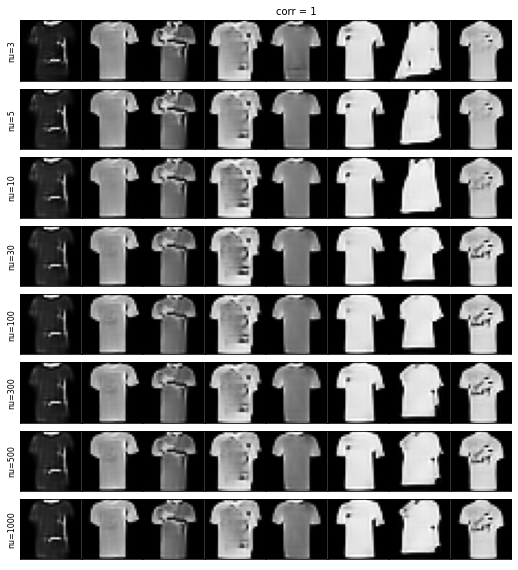

In [148]:
ncol = 8
for corr in CORRS:
    fig, axes = plt.subplots(len(NUS), ncol, figsize=(ncol * 1.1, len(NUS) * 1.25))
    for row, nu in enumerate(NUS):
        x = (samples[(nu, corr)][:ncol].clamp(-1, 1) * 0.5 + 0.5)
        for c in range(ncol):
            axes[row, c].imshow(x[c, 0], cmap='gray', vmin=0, vmax=1)
            axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
        axes[row, 0].set_ylabel('nu=%g' % nu, fontsize=8)
    axes[0, ncol // 2].set_title('corr = %g' % corr, fontsize=10)
    fig.subplots_adjust(wspace=0.02, hspace=0.05)
    fig.savefig(os.path.join(OUT, 'sweep_samples_corr%g.png' % corr), dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

## 9. 자유도 대 지표

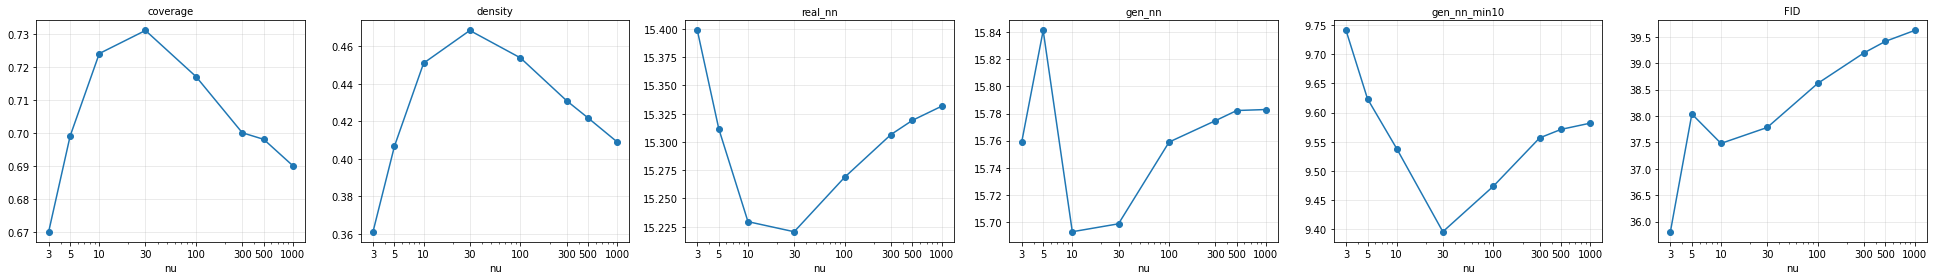


[autoenc]
          nu          corr      coverage       density       real_nn        gen_nn  gen_nn_min10           fid
       3.000         1.000         0.670         0.361        15.399        15.759         9.740        35.807
       5.000         1.000         0.699         0.407        15.312        15.841         9.623        38.037
      10.000         1.000         0.724         0.451        15.230        15.693         9.538        37.480
      30.000         1.000         0.731         0.468        15.221        15.699         9.396        37.782
     100.000         1.000         0.717         0.454        15.269        15.759         9.474        38.618
     300.000         1.000         0.700         0.431        15.307        15.775         9.557        39.195
     500.000         1.000         0.698         0.422        15.319        15.782         9.571        39.414
    1000.000         1.000         0.690         0.409        15.332        15.783         9.582     

In [149]:
def curve(space, corr, key):
    return [r[key] for r in results if r['space'] == space and r['corr'] == corr]

panels = [('coverage', 'coverage'), ('density', 'density'), ('real_nn', 'real_nn'),
          ('gen_nn', 'gen_nn'), ('gen_nn_min10', 'gen_nn_min10'), ('fid', 'FID')]

for space in SPACES:
    fig, ax = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 4))
    for a, (key, title) in zip(ax, panels):
        one = len(CORRS) == 1
        for corr in CORRS:
            a.plot(NUS, curve(space, corr, key), 'o-',
                   label=None if one else 'corr=%g' % corr)
        a.set_xscale('log'); a.set_xlabel('nu')
        a.set_title(title, fontsize=10)
        a.set_xticks(NUS); a.set_xticklabels(['%g' % v for v in NUS])
        if not one:
            a.legend(fontsize=8)
        a.grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, 'sweep_metrics_%s.png' % space), dpi=150, facecolor='white')
    plt.show()

hdr = ['nu', 'corr', 'coverage', 'density', 'real_nn', 'gen_nn', 'gen_nn_min10', 'fid']
for space in SPACES:
    print('\n[%s]' % space)
    print('  '.join('%12s' % h for h in hdr))
    for r in results:
        if r['space'] == space:
            print('  '.join('%12.3f' % r[h] for h in hdr))
    print('  '.join(['%12s' % 'reference', '%12s' % '-']
                    + ['%12.3f' % REF[space][h] for h in ['coverage', 'density', 'real_nn']]
                    + ['%12.3f' % NOVEL[space]['mean'], '%12.3f' % NOVEL[space]['min10'],
                       '%12.3f' % FLOOR[space]]))